# Step 5 — BINNING · burst #21 `bn110920546`
**Status: FINALIZED** — approved by VIKAS. Gate: figure PASS-with-nits (round 5).

How the burst is cut into the intervals that get fitted.

In [1]:
import os, json, glob, hashlib, ast, numpy as np
import astropy.io.fits as fits
from astropy.table import Table
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
BURST = "bn110920546"
sha = lambda p: hashlib.sha256(open(p,"rb").read()).hexdigest()
rel = lambda p: os.path.join(ROOT, p)
appr = json.load(open(rel(f"results/sweep106/{BURST}/APPROVALS.json")))
print("repo:", ROOT, "| burst:", BURST)

repo: /Users/salim/Desktop/Projects/SingleRest/Two_Breaks | burst: bn110920546


In [2]:
STEP = "5"

In [3]:
s = appr[STEP]
print(f'step {STEP}: {s["status"]}  by {s["by"]}  {s["utc"]}')
for f in s.get("feedback", []):
    print(f'\n  PI feedback: {f["text"][:400]}')

step 5: APPROVED  by VIKAS  2026-09-01T03:50:32Z

  PI feedback: REINSTATED by PI ruling 2026-09-01 ('Reinstate - blocks provably unchanged') after the NR-19 cascade demoted this step when n1/n3 backgrounds moved. EVIDENCE: scripts/27b builds the block grid on the REFERENCE NaI alone (n0 for this burst: catalog-brightest AND approved), using n0's OWN windows; the 33 rows are 11 blocks replicated across approved NaIs (edges and significances byte-identical acros


## 1. The blocks

33 rows, but only **11 distinct blocks**: the grid is built on the **reference NaI alone**
(n0 here) using n0's own windows, and the rows are replicated across approved NaIs. That is
why the background amendments to n1/n3 and b0 left the blocks untouched.

In [4]:
b = Table.read(rel(f"results/sweep106/{BURST}/blocks/bb_blocks_spectral_{BURST}.ecsv"), format="ascii.ecsv")
print("rows:", len(b), "| detectors:", sorted(set(str(x) for x in b["DETECTOR"])))
n0 = b[[str(x)=="n0" for x in b["DETECTOR"]]]; n0.sort("BLOCK_INDEX")
edges = {det: [(round(float(x),6), round(float(y),6)) for x,y in
               zip(b[[str(z)==det for z in b["DETECTOR"]]]["T_START"],
                   b[[str(z)==det for z in b["DETECTOR"]]]["T_STOP"])]
         for det in sorted(set(str(x) for x in b["DETECTOR"]))}
print("edges identical across detectors?", len({tuple(v) for v in edges.values()})==1)
print("\n idx      interval (s)      width   significance")
for r in n0:
    print(f'  {int(r["BLOCK_INDEX"]):>2}  {float(r["T_START"]):8.3f} .. {float(r["T_STOP"]):8.3f}  '
          f'{float(r["T_STOP"])-float(r["T_START"]):7.3f}  {float(r["SIGNIFICANCE"]):8.2f}')
print(f'\n  merges: {sum(1 for r in n0 if bool(r["IS_MERGED"]))}   POLY_ORDER values: {sorted(set(int(x) for x in n0["POLY_ORDER"]))}')
print("  (POLY_ORDER = -1 means 3ML chose the order automatically, per channel)")

rows: 33 | detectors: ['n0', 'n1', 'n3']
edges identical across detectors? True

 idx      interval (s)      width   significance
   0    -2.076 ..    0.779    2.854      5.38
   1     0.779 ..    2.017    1.238     10.10
   2     2.017 ..    6.078    4.061     32.41
   3     6.078 ..   18.111   12.033     67.76
   4    18.111 ..   23.782    5.671     43.78
   5    23.782 ..   34.975   11.192     43.66
   6    34.975 ..   45.469   10.494     32.77
   7    45.469 ..   55.534   10.066     25.93
   8    55.534 ..   70.862   15.328     19.37
   9    70.862 ..   89.247   18.385     14.52
  10    89.247 ..  111.304   22.057      9.26

  merges: 0   POLY_ORDER values: [-1]
  (POLY_ORDER = -1 means 3ML chose the order automatically, per channel)


## 2. Block 0 is fragile three ways — and is KEPT by ruling

PI, verbatim: *"it's ok to have block 0 of that 5.38 sigma value"*. Retained is **not** the
same as adequate: it stays flagged, statistics get reported both ways, and it never carries a
claim alone.

In [5]:
sig = [float(x) for x in n0["SIGNIFICANCE"]]
APPLIED_TRIM, ADEQUACY = 5.0, 10.0
print(f'  block 0 significance      : {sig[0]:.4f}')
print(f'  margin over applied trim  : +{sig[0]-APPLIED_TRIM:.3f} sigma ({100*(sig[0]-APPLIED_TRIM)/APPLIED_TRIM:.1f}%)')
print(f'  below adequacy floor ({ADEQUACY:g}) : {[i for i,v in enumerate(sig) if v < ADEQUACY]}')
print("\n  NOTE: this significance is the REFERENCE detector's (n0), replicated across rows.")
print("  Per L6b it is single-detector and UNDERSTATES constraining power (~x2 for 4 plugins).")

  block 0 significance      : 5.3817
  margin over applied trim  : +0.382 sigma (7.6%)
  below adequacy floor (10) : [0, 10]

  NOTE: this significance is the REFERENCE detector's (n0), replicated across rows.
  Per L6b it is single-detector and UNDERSTATES constraining power (~x2 for 4 plugins).


## 3. A documentation defect this step exposed, now fixed

`SIG_TRIM = 4.5` was documented as the edge-trim threshold in both the skill file and the
code's own comment — but `trim_edges` is called with `SIGMA_FLOOR` (5.0); `SIG_TRIM` is used
only for peak detection. The **applied** rule was stricter than the **written** one. PI ruled
*"5.0σ is right — fix the docs"*; the docs and the comment were corrected, behaviour unchanged,
no re-binning.

figure sha matches verified artifact? True
verdict: PASS-WITH-NITS (round 5) — 0 label-primitive mismatches; 3 MUST-FIX (window-tightening undisclosed, bin-adequacy not distinguished, single-detector sigma unqualified)
code finding: scripts/27b:45 SIG_TRIM=4.5 is documented as the edge-trim threshold but trim_edges is called with SIGMA_FLOOR (5.0) at :235; SIG_TRIM is used only for peak detection at :78. VERIFIED by the operating session. Binning.md


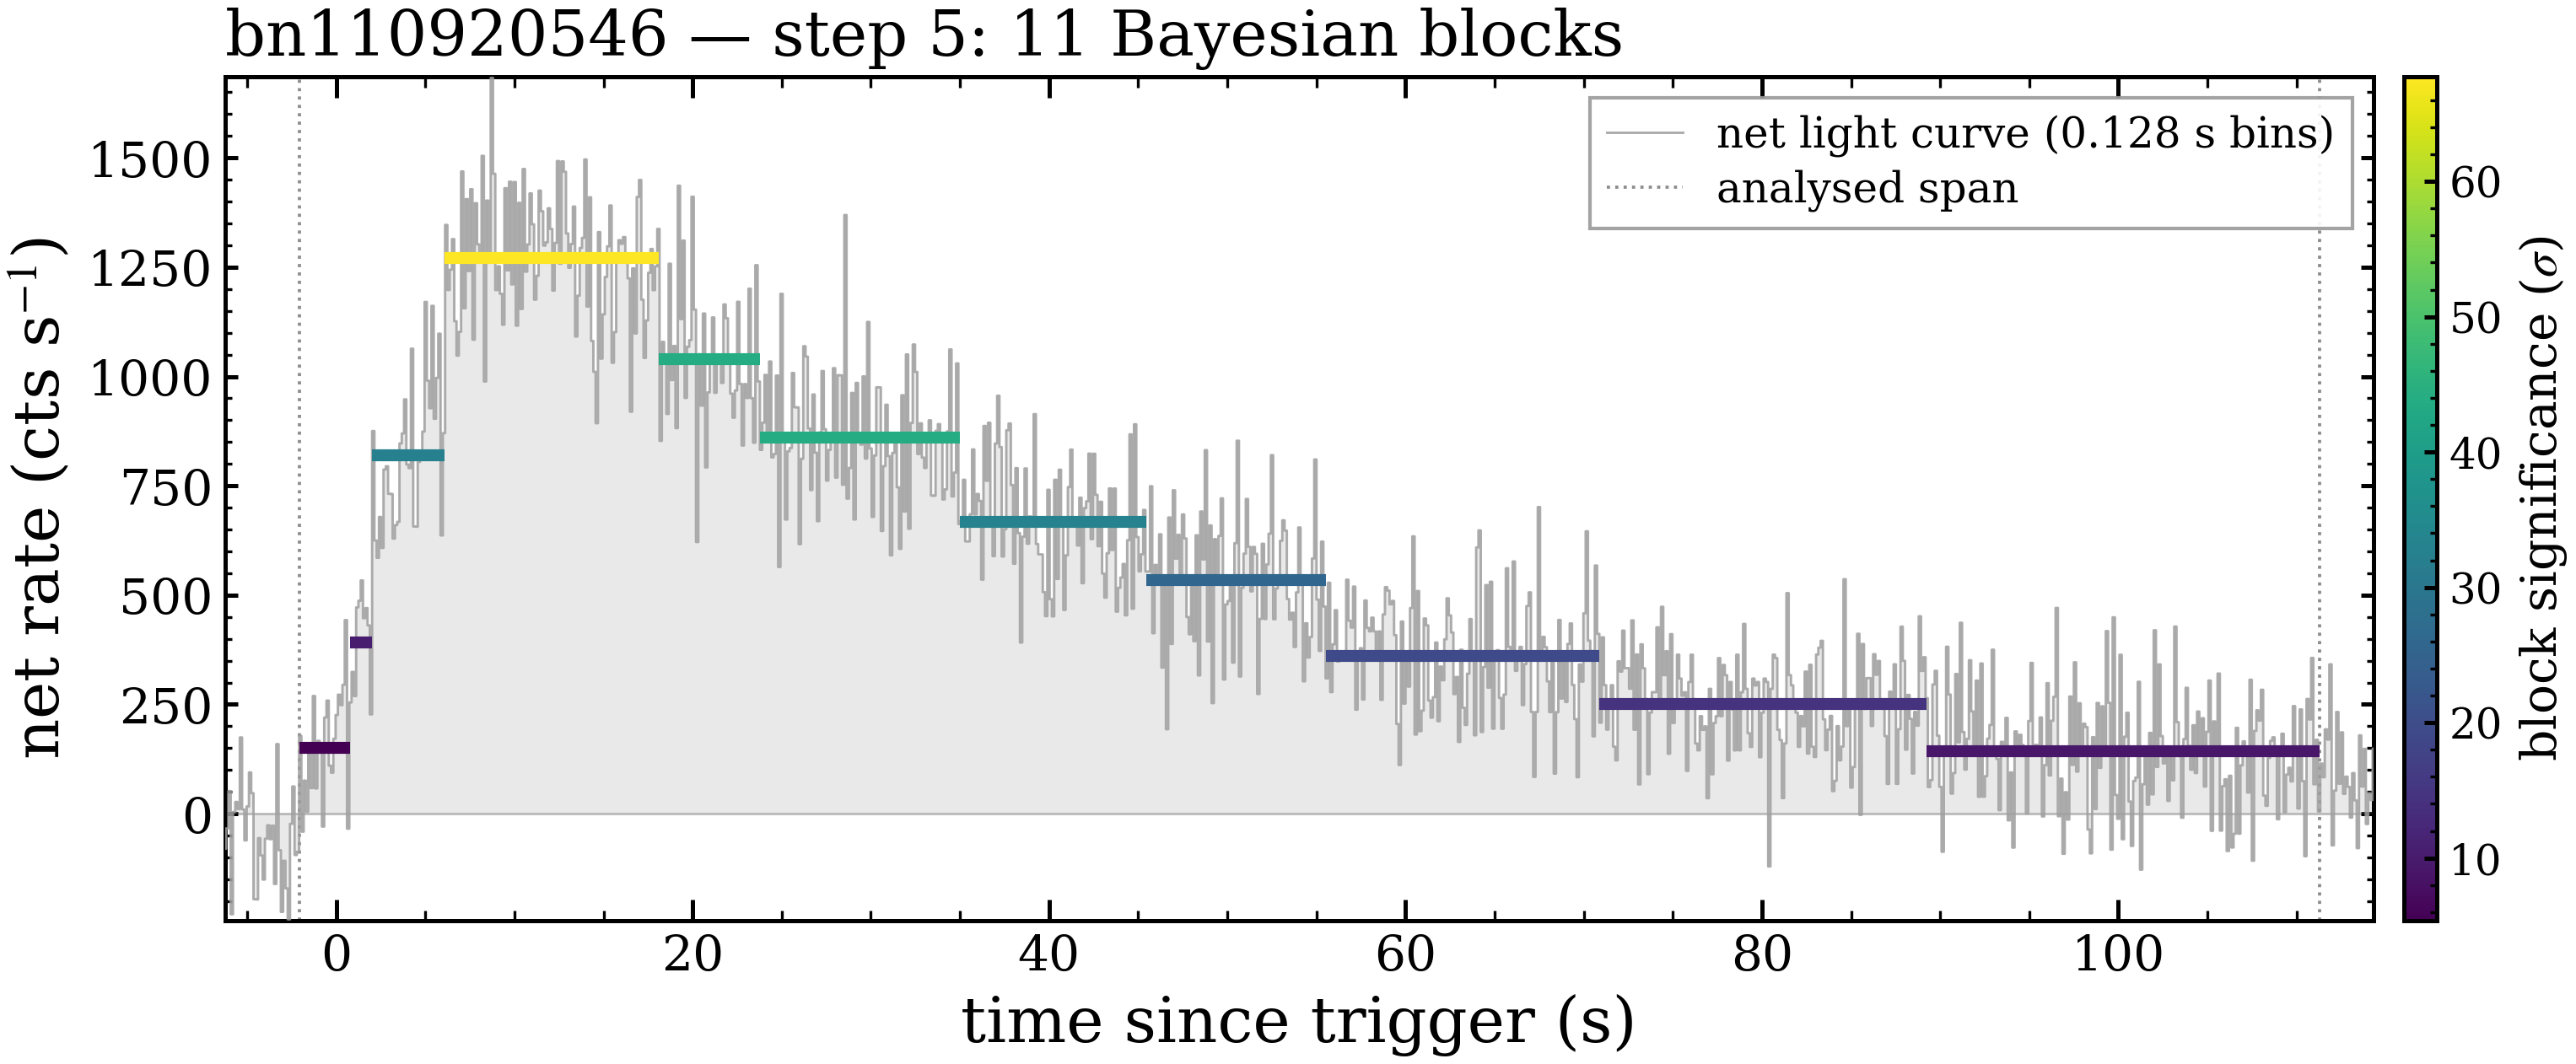

In [6]:
fig = rel(f"results/sweep106/{BURST}/{BURST}_step5_binning.png")
pin = json.load(open(rel("results/campaign/CAMPAIGN_COMMIT_PIN.json")))["gate_verdicts_hash_bound"]["bn110920546_step5"]
print("figure sha matches verified artifact?", pin["artifact_sha256"] == sha(fig))
print("verdict:", pin["verdict"])
print("code finding:", pin.get("code_finding","")[:220])
from IPython.display import Image, display
display(Image(filename=fig))

## 4. Undisclosed on the panel, carried as stated systematics
The window was tightened by **1.16 s** at the left edge (blocks start at −2.076 s, the approved
window at −3.240 s) — `Binning.md` calls presenting that a duty. And the panel does not
distinguish adequate from inadequate blocks; on its colour scale blocks 1 (adequate) and 10
(inadequate) are the same colour to 7 parts in 255.